In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 수정된 6개 티커 목록
tickers = ["QQQM", "QLD", "TQQQ", "PSQ", "QID", "SQQQ"]

# 2. 데이터 다운로드 (뒤에 ['Adj Close']를 붙이지 않고 통째로 받아옵니다)
raw_data = yf.download(tickers, start="2021-01-01")

# 3. 'Adj Close'가 있으면 그것을 쓰고, 없으면 'Close'를 쓰도록 안전장치 추가
if 'Adj Close' in raw_data.columns:
    df = raw_data['Adj Close']
    print("--- 'Adj Close' (수정 종가) 데이터를 성공적으로 가져왔습니다! ---")
else:
    df = raw_data['Close']
    print("--- 'Close' (종가) 데이터를 성공적으로 가져왔습니다! ---")

# 4. 데이터가 잘 들어왔는지 확인
df.head()

[*********************100%***********************]  6 of 6 completed


--- 'Close' (종가) 데이터를 성공적으로 가져왔습니다! ---


Ticker,PSQ,QID,QLD,QQQM,SQQQ,TQQQ
Date,,,,,,
2021-01-04,61.368805,122.689148,27.642574,122.817749,1596.714478,20.756145
2021-01-05,60.864742,120.840408,28.092287,123.798698,1557.401489,21.276695
2021-01-06,61.704838,123.865623,27.338646,122.092903,1621.915283,20.396784
2021-01-07,60.192680,117.815193,28.672964,125.117905,1500.952148,21.870062
2021-01-08,59.394585,114.789993,29.394480,126.741577,1445.510620,22.717745


In [4]:
# 나침반이 될 QQQM의 주가만 따로 떼어내기
qqqm = df['QQQM'].to_frame()

# QQQM의 최근 20일간의 평균 가격(20일 선) 계산해서 새로운 컬럼으로 추가
qqqm['MA20'] = qqqm['QQQM'].rolling(window=20).mean()

# 최근 5일치 데이터 출력해서 확인
qqqm.tail()

,QQQM,MA20
Date,,
2026-06-15,305.886017,297.460265
2026-06-16,300.212585,297.956190
2026-06-17,297.226044,298.392186
2026-06-18,304.167999,298.936057
2026-06-22,303.899994,299.437561


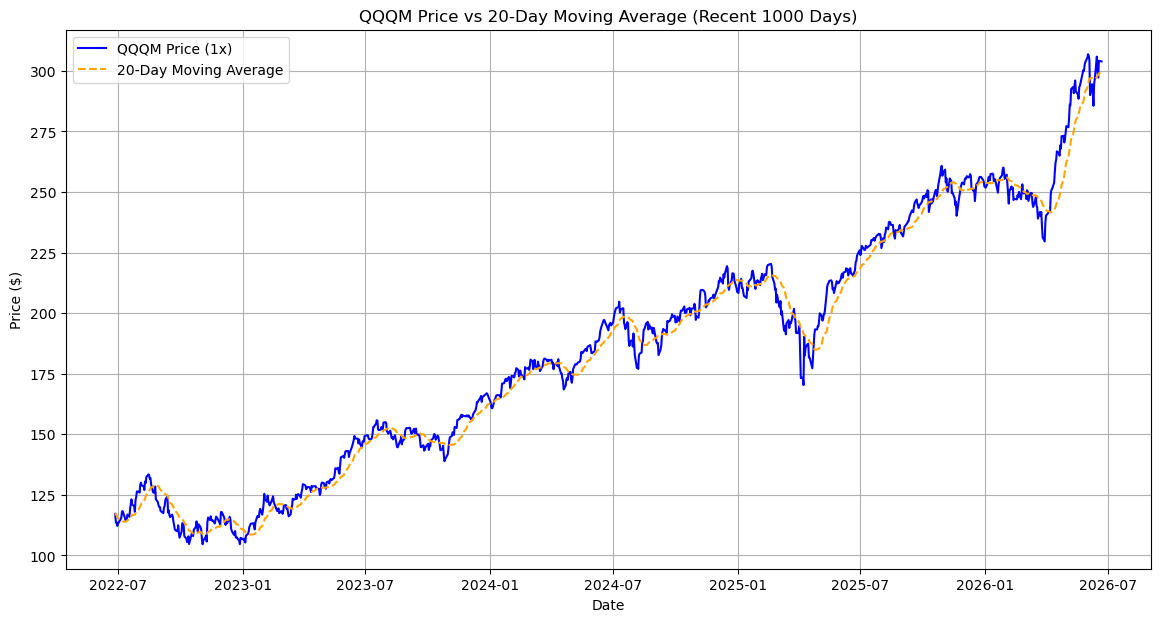

In [9]:
# 전체 데이터는 너무 길어서 복잡하므로, 최근 200일치 데이터만 잘라서 그래프 그리기
TIME = 1000
recent_data = qqqm.tail(TIME)

# 그래프 크기 설정 (가로 14인치, 세로 7인치)
plt.figure(figsize=(14, 7))

# 파란색 실선으로 QQQM 실제 주가 그리기
plt.plot(recent_data['QQQM'], label='QQQM Price (1x)', color='blue')

# 주황색 점선(--)으로 20일 이동평균선 그리기
plt.plot(recent_data['MA20'], label='20-Day Moving Average', color='orange', linestyle='--')

# 그래프에 각종 제목과 설명 달아주기
plt.title(f'QQQM Price vs 20-Day Moving Average (Recent {TIME} Days)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend() # 왼쪽 상단에 라벨(설명 기호) 표시
plt.grid(True) # 배경에 모눈종이 격자 넣기

# 최종 그래프 화면에 출력
plt.show()

In [10]:
import numpy as np

# 1. 매일매일의 '일일 수익률'(전날 대비 몇 % 오르고 내렸는지) 계산
daily_returns = df.pct_change().fillna(0)

# 2. 매일의 매매 신호(Signal) 만들기 (1: 상승장/TQQQ 매수, -1: 하락장/SQQQ 매수)
# qqqm 표에 있는 실제 주가와 20일선을 비교합니다.
signals = np.where(qqqm['QQQM'] > qqqm['MA20'], 1, -1)

# 3. ★가장 중요: '어제' 장마감 때 나온 신호를 보고 '오늘' 아침에 매매하므로 하루 뒤로 미룹니다 (.shift(1))
allocated_signals = pd.Series(signals, index=qqqm.index).shift(1).fillna(0)

# 4. 우리 전략의 일일 수익률 계산하기
strat_returns = np.zeros(len(qqqm))
# 신호가 1(상승장)이었던 날은 TQQQ의 수익률을 내 계좌에 반영
strat_returns[allocated_signals == 1] = daily_returns['TQQQ'][allocated_signals == 1]
# 신호가 -1(하락장)이었던 날은 SQQQ의 수익률을 내 계좌에 반영
strat_returns[allocated_signals == -1] = daily_returns['SQQQ'][allocated_signals == -1]

# 5. 자산의 누적 수익률(돈이 복리로 불어나는 과정) 계산
# 2021년 초에 1달러를 넣었을 때 최종적으로 몇 달러가 되었는지 계산합니다.
qqqm['QQQM_Cum'] = (1 + daily_returns['QQQM']).cumprod()
qqqm['Strategy_Cum'] = (1 + strat_returns).cumprod()

# 6. 최종 결과 출력
print(f"📈 그냥 QQQM 사서 가만히 묻어둔 사람: {qqqm['QQQM_Cum'].iloc[-1]:.2f}배")
print(f"🤖 20일선 타이밍 전략(TQQQ/SQQQ) 투자자: {qqqm['Strategy_Cum'].iloc[-1]:.2f}배")

📈 그냥 QQQM 사서 가만히 묻어둔 사람: 2.47배
🤖 20일선 타이밍 전략(TQQQ/SQQQ) 투자자: 0.78배


In [12]:
'''
2021년 6월 ~ 2026년 6월 
1
조건: 주가가 20일선 밑으로 떨어졌을 때
알고리즘의 판단: "지금 시장이 위험하거나 힘이 없다. 하지만 숏(인버스)을 치면 엇박자 나서 계좌 녹으니까,
가장 안전하고 배당도 주는 기본 1배형 주식(QQQM)만 꽉 쥐고 소나기를 피하자."

2
조건: 주가가 20일선 위로 올라왔지만, 아직 대세 상승(정배열)은 아닐 때
알고리즘의 판단: "바닥치고 올라오기 시작하네? 본격 폭등장인지 페이크(속임수)인지 아직 확실하지 않으니까, 
일단 안전하게 2배 레버리지(QLD)로 기어를 올려서 간을 보자."

3
조건: 주가 > 20일선 > 60일선 순서로 완벽하게 정렬되어 우상향할 때
알고리즘의 판단: "단기 평균(20일)도, 중기 평균(60일)도 다 뚫었다. 이건 완벽한 대세 상승장이다!
락앤롤! 3배 레버리지(TQQQ) 풀악셀 밟고 수익률 극대화하자!"
'''
# 1. 장기 나침반인 60일 이동평균선(MA60) 추가 계산
qqqm['MA60'] = qqqm['QQQM'].rolling(window=60).mean()

# 2. 새로운 전략의 매매 신호(Signal) 만들기
# 초기값은 전부 0 (0일 때는 QQQM 보유)
new_signals = np.zeros(len(qqqm))

# 조건들을 정의합니다.
price = qqqm['QQQM']
ma20 = qqqm['MA20']
ma60 = qqqm['MA60']

# [QLD 매수 조건]: 주가가 20일선보다는 위에 있지만, 아직 강력한 대세 상승(정배열)은 아닐 때
cond_qld = (price > ma20) & (ma20 <= ma60)
new_signals[cond_qld] = 1  # 1번 신호는 QLD

# [TQQQ 매수 조건]: 주가 > 20일선 > 60일선 (완벽한 대세 상승 강력한 추세장)
cond_tqqq = (price > ma20) & (ma20 > ma60)
new_signals[cond_tqqq] = 2  # 2번 신호는 TQQQ

# 3. 매매 신호를 하루 뒤로 미룸 (Data Leakage 방지 안전장치)
allocated_new_signals = pd.Series(new_signals, index=qqqm.index).shift(1).fillna(0)

# 4. 새로운 전략의 일일 수익률 계산
new_strat_returns = np.zeros(len(qqqm))

# 신호가 0인 날은 QQQM 수익률 반영
new_strat_returns[allocated_new_signals == 0] = daily_returns['QQQM'][allocated_new_signals == 0]
# 신호가 1인 날은 QLD 수익률 반영
new_strat_returns[allocated_new_signals == 1] = daily_returns['QLD'][allocated_new_signals == 1]
# 신호가 2인 날은 TQQQ 수익률 반영
new_strat_returns[allocated_new_signals == 2] = daily_returns['TQQQ'][allocated_new_signals == 2]

# 5. 새로운 전략의 누적 수익률 계산
qqqm['New_Strategy_Cum'] = (1 + new_strat_returns).cumprod()

# 6. 최종 성적표 비교 출력
print(f"📈 [원조] 그냥 QQQM 사서 가만히 묻어둔 사람: {qqqm['QQQM_Cum'].iloc[-1]:.2f}배")
print(f"💀 [이전] 20일선 TQQQ/SQQQ 엇박자 투자자: {qqqm['Strategy_Cum'].iloc[-1]:.2f}배")
print(f"🔥 [새전략] 하방방어 + 레버리지 가속도 투자자: {qqqm['New_Strategy_Cum'].iloc[-1]:.2f}배")

📈 [원조] 그냥 QQQM 사서 가만히 묻어둔 사람: 2.47배
💀 [이전] 20일선 TQQQ/SQQQ 엇박자 투자자: 0.78배
🔥 [새전략] 하방방어 + 레버리지 가속도 투자자: 3.72배


In [13]:
# 6번째 칸에 복사해서 실행하세요.
# 각 자산별로 2021년 첫날 사서 가만히 묻어둔 누적 수익률 계산
qqqm['QLD_Cum'] = (1 + daily_returns['QLD']).cumprod()
qqqm['TQQQ_Cum'] = (1 + daily_returns['TQQQ']).cumprod()

print("===== 2021년 1월 ~ 2026년 6월 최종 성적표 (원금 1.00배 기준) =====")
print(f"📈 [1배 QQQM 거치] 그냥 묻어두기: {qqqm['QQQM_Cum'].iloc[-1]:.2f}배")
print(f"🚀 [2배 QLD  거치] 그냥 묻어두기: {qqqm['QLD_Cum'].iloc[-1]:.2f}배")
print(f"💥 [3배 TQQQ 거치] 그냥 묻어두기: {qqqm['TQQQ_Cum'].iloc[-1]:.2f}배")
print(f"---")
print(f"🔥 [🤖 우리 새전략] 하방방어 + 가속도 투자: {qqqm['New_Strategy_Cum'].iloc[-1]:.2f}배")

===== 2021년 1월 ~ 2026년 6월 최종 성적표 (원금 1.00배 기준) =====
📈 [1배 QQQM 거치] 그냥 묻어두기: 2.47배
🚀 [2배 QLD  거치] 그냥 묻어두기: 3.53배
💥 [3배 TQQQ 거치] 그냥 묻어두기: 3.98배
---
🔥 [🤖 우리 새전략] 하방방어 + 가속도 투자: 3.72배


C:\Users\kmh12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


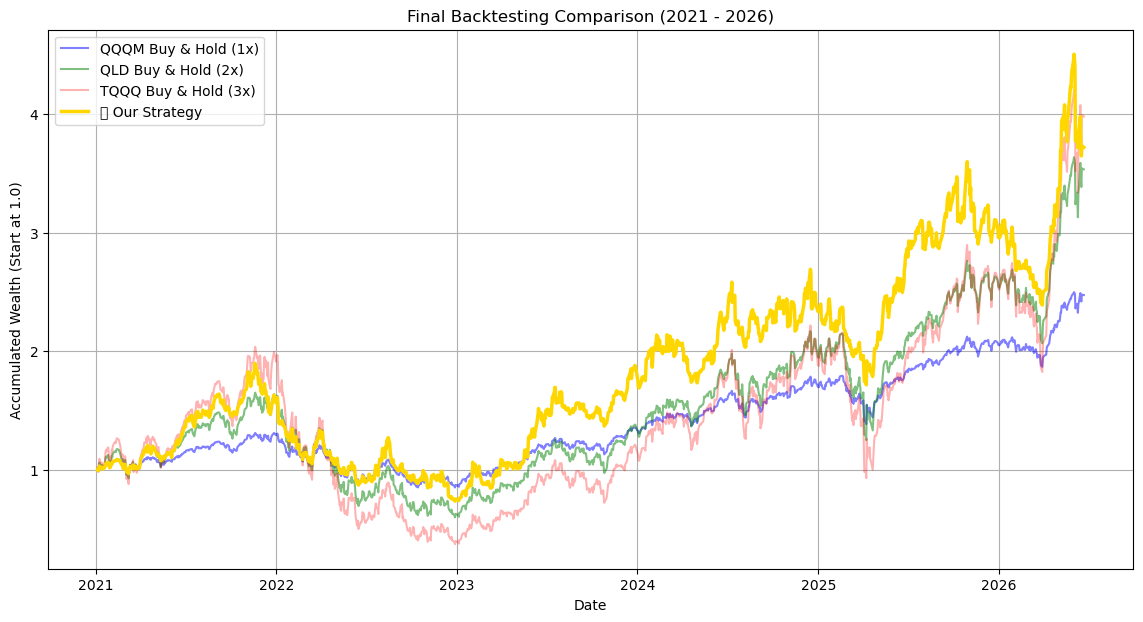

In [14]:
# 7번째 칸에 복사해서 실행하세요.
plt.figure(figsize=(14, 7))

# 4개 자산의 누적 수익률 그래프 그리기
plt.plot(qqqm['QQQM_Cum'], label='QQQM Buy & Hold (1x)', color='blue', alpha=0.5)
plt.plot(qqqm['QLD_Cum'], label='QLD Buy & Hold (2x)', color='green', alpha=0.5)
plt.plot(qqqm['TQQQ_Cum'], label='TQQQ Buy & Hold (3x)', color='red', alpha=0.3)
plt.plot(qqqm['New_Strategy_Cum'], label='🤖 Our Strategy', color='gold', linewidth=2.5)

plt.title('Final Backtesting Comparison (2021 - 2026)')
plt.xlabel('Date')
plt.ylabel('Accumulated Wealth (Start at 1.0)')
plt.legend()
plt.grid(True)
plt.show()